## Loading data

In [48]:
file = open("Royal_data.txt","r")
royal_data = file.readlines()
file.close()

for line in royal_data:
    print(line)

The future king is the prince

Daughter is the princess

Son is the prince

Only a man can be a king

Only a woman can be a queen

The princess will be a queen

The prince is a strong man

The princess is a beautiful woman

Prince is only a boy now

Prince will be king

A boy will be a man


## Removing '\n' from the end of every sentence and convert the sentence into lowercase

In [49]:
for i in range(len(royal_data)):
    royal_data[i] = royal_data[i].lower().replace('\n','')

for line in royal_data:
    print(line)

the future king is the prince
daughter is the princess
son is the prince
only a man can be a king
only a woman can be a queen
the princess will be a queen
the prince is a strong man
the princess is a beautiful woman
prince is only a boy now
prince will be king
a boy will be a man


## Removing stop words

In [50]:
stopwords = ['the', 'is', 'will', 'be', 'a', 'only', 'can', 'their', 'now', 'and', 'at', 'it']

filtered_data = []

for line in royal_data:
    new_line = []
    for word in line.split(' '):
        if word not in stopwords:
            new_line.append(word)
    filtered_data.append(new_line)

for line in filtered_data:
    print(line)

['future', 'king', 'prince']
['daughter', 'princess']
['son', 'prince']
['man', 'king']
['woman', 'queen']
['princess', 'queen']
['prince', 'strong', 'man']
['princess', 'beautiful', 'woman']
['prince', 'boy']
['prince', 'king']
['boy', 'man']


## Creating bigrams

In [51]:
bigrams = []

for words_list in filtered_data:
    for i in range(len(words_list) - 1):
        for j in range(i+1, len(words_list)):
            word_1 = words_list[i]
            word_2 = words_list[j]
            bigrams.append([word_1, word_2])
            bigrams.append([word_2, word_1])

for bi in bigrams:
    print(bi)

['future', 'king']
['king', 'future']
['future', 'prince']
['prince', 'future']
['king', 'prince']
['prince', 'king']
['daughter', 'princess']
['princess', 'daughter']
['son', 'prince']
['prince', 'son']
['man', 'king']
['king', 'man']
['woman', 'queen']
['queen', 'woman']
['princess', 'queen']
['queen', 'princess']
['prince', 'strong']
['strong', 'prince']
['prince', 'man']
['man', 'prince']
['strong', 'man']
['man', 'strong']
['princess', 'beautiful']
['beautiful', 'princess']
['princess', 'woman']
['woman', 'princess']
['beautiful', 'woman']
['woman', 'beautiful']
['prince', 'boy']
['boy', 'prince']
['prince', 'king']
['king', 'prince']
['boy', 'man']
['man', 'boy']


## Getting a list of unique words

In [52]:
all_words = []

for bi in bigrams:
    all_words.extend(bi)

unique_words = list(set(all_words))
unique_words.sort()
print(unique_words, len(unique_words))

['beautiful', 'boy', 'daughter', 'future', 'king', 'man', 'prince', 'princess', 'queen', 'son', 'strong', 'woman'] 12


## Creating dictionary of words

In [53]:
words_dict = {}

for i in range(len(unique_words)):
    words_dict[unique_words[i]] = i

words_dict

{'beautiful': 0,
 'boy': 1,
 'daughter': 2,
 'future': 3,
 'king': 4,
 'man': 5,
 'prince': 6,
 'princess': 7,
 'queen': 8,
 'son': 9,
 'strong': 10,
 'woman': 11}

## Performing one-hot encoding


In [54]:
import numpy as np

size = len(unique_words)

onehot_data = np.zeros((size, size), dtype=np.float32)

for i in range(size):
    onehot_data[i][i] = 1

onehot_dict = {}
for i in range(size):
    onehot_dict[unique_words[i]] = onehot_data[i]

for key, value in onehot_dict.items():
    print(key, ":", value)

beautiful : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
boy : [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
daughter : [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
future : [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
king : [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
man : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
prince : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
princess : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
queen : [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
son : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
strong : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
woman : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [55]:
# assign to X and Y

X = []
Y = []

for bi in bigrams:
    X.append(onehot_dict[bi[0]])
    Y.append(onehot_dict[bi[1]])

X = np.array(X)
Y = np.array(Y)

print(f"X = {X}")
print(f"Y = {Y}")

X = [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0

## Model

In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class SimpleNN(nn.Module):
    def __init__(self, input_size, embed_size, output_size):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, embed_size)
        self.fc2 = nn.Linear(embed_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x
    
size = len(unique_words)
model = SimpleNN(input_size=size, embed_size=2, output_size=size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [57]:
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)
Y_indices = torch.argmax(Y_tensor, dim=1)  # long tensor with class indices

In [58]:
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = model(X_tensor)            # Forward pass
    loss = criterion(outputs, Y_indices) # Use class indices here
    loss.backward()                      # Backpropagation
    optimizer.step()                     # Update weights
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 2.6615
Epoch 100, Loss: 2.5195
Epoch 200, Loss: 2.3503
Epoch 300, Loss: 2.1842
Epoch 400, Loss: 2.0285
Epoch 500, Loss: 1.8839
Epoch 600, Loss: 1.7632
Epoch 700, Loss: 1.6702
Epoch 800, Loss: 1.5994
Epoch 900, Loss: 1.5442


In [59]:
# save the model state
torch.save(model.state_dict(), "model_weights.pth")

In [60]:
print(model.state_dict())
print("FC2: ",model.state_dict()["fc2.weight"])

weight = model.state_dict()["fc2.weight"].cpu().detach().numpy()

OrderedDict([('fc1.weight', tensor([[ 1.2264, -0.8009,  1.1055, -1.0048, -1.2131, -0.8601, -0.7684,  1.1175,
          0.9472, -0.9267, -0.9875,  0.8355],
        [ 1.1311,  0.9558,  1.1716, -0.2981,  0.7130, -0.7808, -0.8779, -0.3303,
          1.1640,  0.9909,  0.9463,  0.5495]])), ('fc1.bias', tensor([-0.1639,  0.4551])), ('fc2.weight', tensor([[ 1.5144,  0.2253],
        [-0.5235, -1.3274],
        [ 1.3375, -0.5573],
        [-1.4230, -0.0261],
        [-1.4280, -1.4333],
        [-0.8844,  0.8421],
        [-1.3449,  1.0076],
        [ 1.2496,  1.3864],
        [ 1.0510, -0.0159],
        [ 0.0907, -1.3310],
        [-1.1545, -1.2078],
        [ 1.4187,  0.5936]])), ('fc2.bias', tensor([-0.1181,  0.2798, -0.4528, -0.6293,  0.0547,  0.0454,  0.0360, -0.2405,
         0.3511,  0.1509, -0.3384,  0.1824]))])
FC2:  tensor([[ 1.5144,  0.2253],
        [-0.5235, -1.3274],
        [ 1.3375, -0.5573],
        [-1.4230, -0.0261],
        [-1.4280, -1.4333],
        [-0.8844,  0.8421],
    

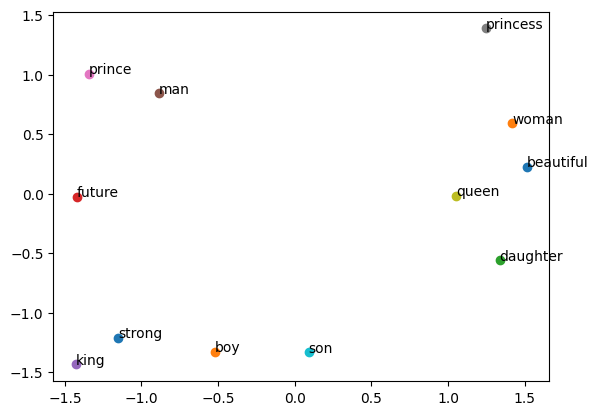

In [61]:
word_embeddings = {}

for word in unique_words:
    word_embeddings[word] = weight[words_dict[word]]

import matplotlib.pyplot as plt

# plt.figure(figsize = (10, 10))
for word in list(words_dict.keys()):
    coord = word_embeddings.get(word)
    plt.scatter(coord[0], coord[1])
    plt.annotate(word, (coord[0], coord[1]))

plt.savefig('img.jpg')